In [1]:

import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
import numpy as np
import scipy.io 
import mne
import os
import sys

epoch_path = "E:/workspace/kiki_conformity_data/Trust_Clean2" # 分析哪个roi就输入哪个文件夹的数据
behavior_path = "E:/workspace/kiki_conformity_data/Find_trials_combine" # 分析哪个roi就输入哪个文件夹的数据

subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

subjects = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 35, 36, 37, 38, 39, 40] # vmpfc 122  (删除 119, 120后结果变差)  116,    # 104 134fast错误太少，少于4  120 134 toofast太少

len(subjects)


38

In [2]:
channel_location_dict = {"Fp1":	[-26.25, 83, -18.25],
"Fp2": [26.25, 83, -18.25],
"F3": [-48.75, 57.5, 36.5],
"F4": [48.75, 57.5, 36.5],
"C3": [-63.75, -13, 65.75],
"C4": [63.75, -13, 65.75],
"P3": [-48, -86.5, 53],
"P4": [48, -86.5, 53],
"O1": [-27, -118, 4.25],
"O2": [27, -118, 4.25],
"F7": [-69, 44, -18.25],
"F8": [69, 44, -18.25],
"T7": [-84, -18.25, -13],
"T8": [84, -18.25, -13],
"P7": [-69, -80.5, -4.75],
"P8": [69, -80.5, -4.75],
"Fz": [0, 63.5, 59],
"Cz": [0, -10, 99.5],
"Pz": [0, -88, 77],
"FC1": [-32.25, 28.25, 77.75],
"FC2": [32.25, 28.25, 77.75],
"CP1": [-35.25, -52, 90.5],
"CP2": [35.25, -52, 90.5],
"FC5": [-75.75, 20, 21.5],
"FC6": [75.75, 20, 21.5],
"CP5": [-78, -51.25, 31.25],
"CP6": [78, -51.25, 31.25],
"FT9": [-72.75, 8.75, -55.75],
"FT10": [72.75, 8.75, -55.75],
"TP9": [-71.25, -49, -49.75],
"TP10": [71.25, -49, -49.75],
"F1": [-25.5, 62, 53.75],
"F2": [25.5, 62, 53.75],
"C1": [-35.25, -11.5, 89.75],
"C2": [35.25, -11.5, 89.75],
"P1": [-27, -88, 70.25],
"P2": [27, -88, 70.25],
"AF3": [-32.25, 80.75, 11.75],
"AF4": [32.25, 80.75, 11.75],
"FC3": [-59.25, 25.25, 54.5],
"FC4": [59.25, 25.25, 54.5],
"CP3": [-63, -52, 66.5],
"CP4": [63, -52, 66.5],
"PO3": [-31.5, -109.75, 32.75],
"PO4": [31.5, -109.75, 32.75],
"F5": [-63, 51.5, 11.75],
"F6": [63, 51.5, 11.75],
"C5": [-81.75, -14.5, 29],
"C6": [81.75, -14.5, 29],
"P5": [-63.75, -83.5, 26.75],
"P6": [63.75, -83.5, 26.75],
"AF7": [-50.25, 68, -19],
"AF8": [50.25, 68, -19],
"FT7": [-79.5, 15.5, -16],
"FT8": [79.5, 15.5, -16],
"TP7": [-80.25, -49.75, -8.5],
"TP8": [80.25, -49.75, -8.5],
"PO7": [-50.25, -103, 0.5],
"PO8": [50.25, -103, 0.5],
"Fpz": [0, 83, -18.25],
"CPz": [0, -53.5, 98],
"POz": [0, -109, 44],
"Oz": [0, -122.5, 8]}
# ['Fp1', 'Fp2', 'Fz', 'Cz', 'Pz', 'Fpz', 'CPz', 'POz', 'Oz'].
mymontage = mne.channels.make_dig_montage(ch_pos=channel_location_dict)#, nasion=[0, -10, 99.5], lpa=[-71.25, -49, -49.75], 
#                                        rpa=[71.25, -49, -49.75])

In [3]:
#个体水平
from mne.time_frequency import tfr_morlet
from pathlib import Path

freqs=np.arange(4, 8, 1)
# freqs=np.arange(8, 13, 1)
# freqs=np.arange(13, 30, 1)

# n_cycles = 10
n_cycles=freqs/4  # 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


# n_cycles =4
time_span = 100
ch_names = []
decision_time_range = [-1.0, 5] # decision前后  0.9
baseline_range = [-1.1, 1.0]  # baseline前后 0.3s


all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0


    # 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    # task_10_rows = behavior_trial[behavior_trial['image_type'] == 308]
    task_10_rows = behavior_trial[behavior_trial['image_type'] == 309]

    # 2. 提取rating列并排序
    ratings_sorted = task_10_rows['rating'].sort_values(ascending=False).values

    # 2. rating列减去30
    task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30

    # 3. 计算grouprating减去调整后的rating
    task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']

    # 4. 分为正差和负差两组
    positive_diff_rows = task_10_rows[task_10_rows['difference'] > 0]  # 差值为正的行
    negative_diff_rows = task_10_rows[task_10_rows['difference'] < 0]  # 差值为负的行

    positive_indices = positive_diff_rows.index.tolist()  # 正差组的行索引
    negative_indices = negative_diff_rows.index.tolist()  # 负差组的行索引
    print(positive_indices)
    if not positive_indices or not negative_indices:
        continue  # 跳过本次循环
    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[negative_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[positive_indices], freqs, n_cycles=n_cycles, return_itc=False, average = True, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio

    # 计算 Human 试次的平均 TFR
    human_mean_tfr = np.mean(all_human_trials_mean_tfr.data, axis=1)  # 计算平均值
    AI_mean_tfr = np.mean(all_AI_trials_mean_tfr.data, axis=1)

    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr)
    all_sub_AI_data.append(AI_mean_tfr)  # 确保变量名与列表匹配




Extracting parameters from E:\workspace\kiki_conformity_data\Trust_Clean2\sub2_1_1.set...
Not setting metadata
Not setting metadata
280 matching events found


<ipython-input-3-daac586d86be>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-3-daac586d86be>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
[160, 161, 162, 167, 169, 172]


...

<ipython-input-3-daac586d86be>:34: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-3-daac586d86be>:37: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
[163, 165, 192]
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


<ipython-input-3-daac586d86be>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30
<ipython-input-3-daac586d86be>:62: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s 

In [3]:
#接收到social influence时的活动
from mne.time_frequency import tfr_morlet
from pathlib import Path

freqs=np.arange(4, 8, 1)
# freqs=np.arange(8, 13, 1)
# freqs=np.arange(13, 30, 1)

# n_cycles = 10
n_cycles=freqs/4  # 4
for i in range(len(n_cycles)):
    if n_cycles[i] < 2:  # 2
        n_cycles[i] = 2 # 2
    if n_cycles[i] > 10:
        n_cycles[i] = 10


# n_cycles =4
time_span = 100
ch_names = []
# 1. 定义时间窗口（feedback_time 对齐后）
tmin, tmax = -0.2, 1.0  # 单位：秒（-200ms 到 +1000ms）



all_sub_human_data = []
all_sub_AI_data = []
human_trial_num, AI_trial_num = 0, 0
tmin, tmax = -0.2, 1.0  # 单位：秒（-200ms 到 +1000ms）


# 遍历所有被试
for i in range(len(subjects)):
    # 读取 EEG 数据
    eeg_path = Path(f"E:/workspace/kiki_conformity_data/Trust_Clean2/sub{subjects[i]}_1_1.set")
    EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号
    
    EEG_epochs.drop_channels(['VEOG'])
    EEG_epochs.set_montage(mymontage)
    EEG_epochs.crop(-1.1, 5)
    # 降采样
    EEG_epochs.resample(250)

    # 读取行为数据
    behavior_path = Path("E:/workspace/kiki_conformity_data/Find_trials_combine")
    file_path = behavior_path / f"task_all_subject{subjects[i]:03d}.xlsx"
    behavior_trial = pd.read_excel(file_path)
    # task3_data = behavior_trial[behavior_trial["task"].astype(str) == "30"]
    print(len(behavior_trial))

    # 提取不同条件是第几个试次

    # 1. 筛选task列值为10的行
    # task_10_rows = behavior_trial[behavior_trial['image_type'] == 308]
    task_10_rows = behavior_trial[behavior_trial['image_type'] == 309]

    # 2. 提取rating列并排序
    ratings_sorted = task_10_rows['rating'].sort_values(ascending=False).values

    # 2. rating列减去30
    task_10_rows['rating_adjusted'] = task_10_rows['rating'] - 30

    # 3. 计算grouprating减去调整后的rating
    task_10_rows['difference'] = task_10_rows['grouprating'] - task_10_rows['rating_adjusted']

    # 4. 分为正差和负差两组
    positive_diff_rows = task_10_rows[task_10_rows['difference'] > 0]  # 差值为正的行
    negative_diff_rows = task_10_rows[task_10_rows['difference'] < 0]  # 差值为负的行

    positive_indices = positive_diff_rows.index.tolist()  # 正差组的行索引
    negative_indices = negative_diff_rows.index.tolist()  # 负差组的行索引
    print(positive_indices)
    if not positive_indices or not negative_indices:
        continue  # 跳过本次循环
    # 2. 提取两组 trials 的 feedback_time
    positive_fbt = behavior_trial.loc[positive_indices, 'feedback_time'].values / 1000  # 转秒
    negative_fbt = behavior_trial.loc[negative_indices, 'feedback_time'].values / 1000  # 转秒

    # 统一计算tfr
    all_human_trials_mean_tfr = tfr_morlet(EEG_epochs[negative_indices], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=5)  # lower
    all_AI_trials_mean_tfr = tfr_morlet(EEG_epochs[positive_indices], freqs, n_cycles=n_cycles, return_itc=False, average = False, use_fft=True, n_jobs=5)   # higher

    # 基线校正
    all_human_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    all_AI_trials_mean_tfr.apply_baseline(mode='zlogratio', baseline=(-0.5, 0)) # 'mean' | 'ratio' | 'logratio' | 'percent' | 'zscore' | 'zlogratio'
    # zlogratio


    # 计算偏移的水平
    human_mean_tfr_alter = []
    AI_mean_tfr_alter = []
    for iter_trial in range(len(all_human_trials_mean_tfr.data)):
        # iter_trial_time = positive_fbt[iter_trial] + 1) * 
        human_mean_tfr_alter.append(all_human_trials_mean_tfr[iter_trial].crop(negative_fbt[iter_trial]-0.2, negative_fbt[iter_trial]+1).data)

    for iter_trial in range(len(all_AI_trials_mean_tfr.data)):
        # iter_trial_time = positive_fbt[iter_trial] + 1) * 
        AI_mean_tfr_alter.append(all_AI_trials_mean_tfr[iter_trial].crop(positive_indices[iter_trial]-0.2, positive_indices[iter_trial]+1).data)

    # 计算 Human 试次的平均 TFR
    human_mean_tfr_alter = np.mean(human_mean_tfr_alter, axis=1)  # 计算平均值
    AI_mean_tfr_alter = np.mean(AI_mean_tfr_alter, axis=1)


    # 存入 list，而不是 `append` 到 `AverageTFR` 对象
    all_sub_human_data.append(human_mean_tfr_alter)
    all_sub_AI_data.append(AI_mean_tfr_alter)  # 确保变量名与列表匹配




Extracting parameters from E:\workspace\kiki_conformity_data\Trust_Clean2\sub2_1_1.set...
Not setting metadata
Not setting metadata
280 matching events found


<ipython-input-3-a0dd3cba2b43>:36: RuntimeWarning: At least one epoch has multiple events. Only the latency of the first event will be retained.
  EEG_epochs = mne.read_epochs_eeglab(eeg_path, event_id=None)  # 允许多个事件编号


No baseline correction applied
0 projection items activated
Ready.


<ipython-input-3-a0dd3cba2b43>:39: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  EEG_epochs.set_montage(mymontage)


280
[160, 161, 162, 167, 169, 172]


...

Not setting metadata


[Parallel(n_jobs=5)]: Done  15 tasks      | elapsed:    0.6s
[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.8s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Done  27 tasks      | elapsed:    0.0s


Not setting metadata
Applying baseline correction (mode: zlogratio)
Applying baseline correction (mode: zlogratio)


[Parallel(n_jobs=5)]: Done  63 out of  63 | elapsed:    0.0s finished


ValueError: No samples remain when using tmin=159.8 and tmax=161 (original time bounds are [-1.1, 5.0])

In [4]:
human_mean_tfr_alter.shape

AttributeError: 'list' object has no attribute 'shape'

In [ ]:
np.array(all_sub_human_data)[:,1,1]

In [ ]:
np.array(all_sub_human_data).shape

In [4]:
import mne
from mne.channels import find_ch_adjacency
from mne.datasets import sample
from mne.stats import combine_adjacency, spatio_temporal_cluster_test
from mne.viz import plot_compare_evokeds



# create a new epochs info
info = mne.create_info(ch_names = EEG_epochs.ch_names, ch_types = 'eeg', sfreq = 250)

# create a new ROI based epochs
all_sub_human_epoch = mne.EpochsArray(data = all_sub_human_data, info = info, tmin=-1.1)
all_sub_AI_epoch = mne.EpochsArray(data = all_sub_AI_data, info = info, tmin=-1.1)

# all_sub_imminent_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
# all_sub_moderate_epoch.apply_baseline(baseline=(baseline_range[0]-baseline_range[1]+decision_time_range[0]+0.6, baseline_range[0]-baseline_range[1]+decision_time_range[0]+1.1))
all_sub_human_epoch.set_montage(mymontage)
all_sub_AI_epoch.set_montage(mymontage)

adjacency, ch_names = find_ch_adjacency(all_sub_human_epoch.info, ch_type="eeg")

print(type(adjacency))  # it's a sparse matrix!

all_sub_human_epoch.resample(100)
all_sub_AI_epoch.resample(100)


all_sub_human_epoch = all_sub_human_epoch.crop(-0.5, 1)
all_sub_AI_epoch = all_sub_AI_epoch.crop(-0.5, 1)

all_sub_human_epoch.apply_baseline(baseline = (-0.5,0))
all_sub_AI_epoch.apply_baseline(baseline = (-0.5,0)) 


Not setting metadata
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Not setting metadata
Not setting metadata
24 matching events found
No baseline correction applied
0 projection items activated
0 bad epochs dropped
Could not find a adjacency matrix for the data. Computing adjacency based on Delaunay triangulations.
-- number of adjacent vertices : 63
<class 'scipy.sparse.csr.csr_matrix'>


<ipython-input-4-4c1667195d24>:18: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_human_epoch.set_montage(mymontage)
<ipython-input-4-4c1667195d24>:19: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  all_sub_AI_epoch.set_montage(mymontage)


Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


Number of events,24
Events,1: 24
Time range,-0.500 – 1.000 sec
Baseline,-0.500 – 0.000 sec


In [ ]:
# spatio_temporal_cluster_test
n_permutations = 1000

# anova
# 两者之间的显著性
# T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([all_smooth_hgb_slow_crop.data, all_smooth_hgb_fast_crop.data],
#                                                                 out_type='mask', n_permutations=n_permutations, n_jobs=6,tail=0
#                                                                 ,verbose=None, t_power=0) #, stat_fun=scipy.stats.ttest_ind())

# all_smooth_hgb_fast = all_smooth_hgb_fast.crop(-0.1, 1.1)
# all_smooth_hgb_slow = all_smooth_hgb_slow.crop(-0.1, 1.1)



X = [
    all_sub_human_epoch.get_data().transpose(0, 2, 1),
    all_sub_AI_epoch.get_data().transpose(0, 2, 1),
]

def stat_fun_ttest_ind(X,Y):
    return scipy.stats.ttest_ind(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_sub_human_epoch.get_data().shape[0] + all_sub_AI_epoch.get_data().shape[0] - 2
t_value_threshold = t.ppf(1 - 0.05, degrees_of_freedom)
# print(t_value_threshold)

# run the cluster based permutation analysis
t_obs, clusters, cluster_pv, h0 = spatio_temporal_cluster_test(
    X,
    n_permutations=n_permutations,
    tail=0,
    n_jobs=1,
    buffer_size=None,
    adjacency=adjacency,
    t_power=1,
    out_type = 'mask',
    threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind
)

cluster_pv


[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
(63, 151)


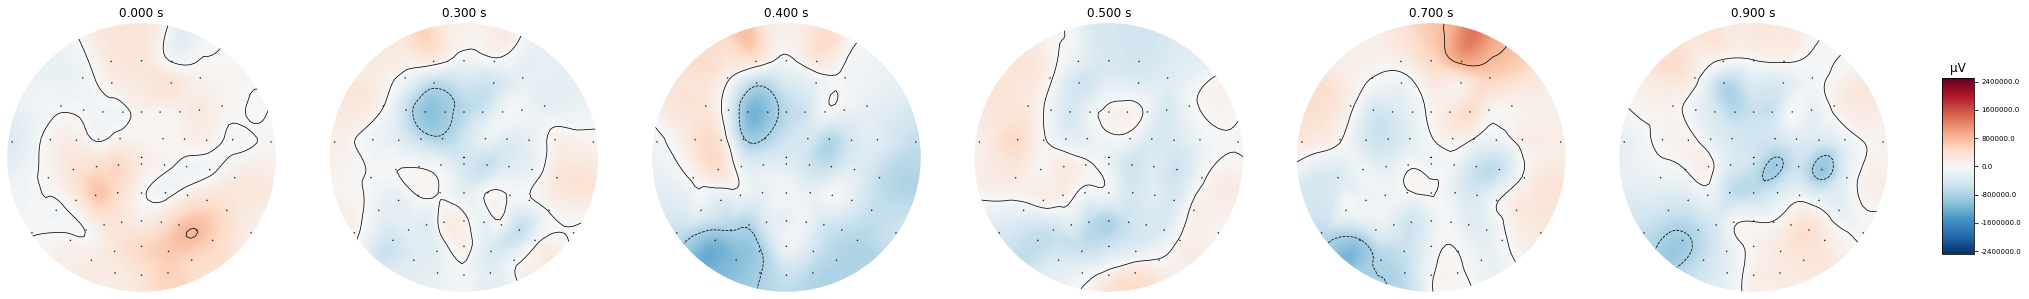

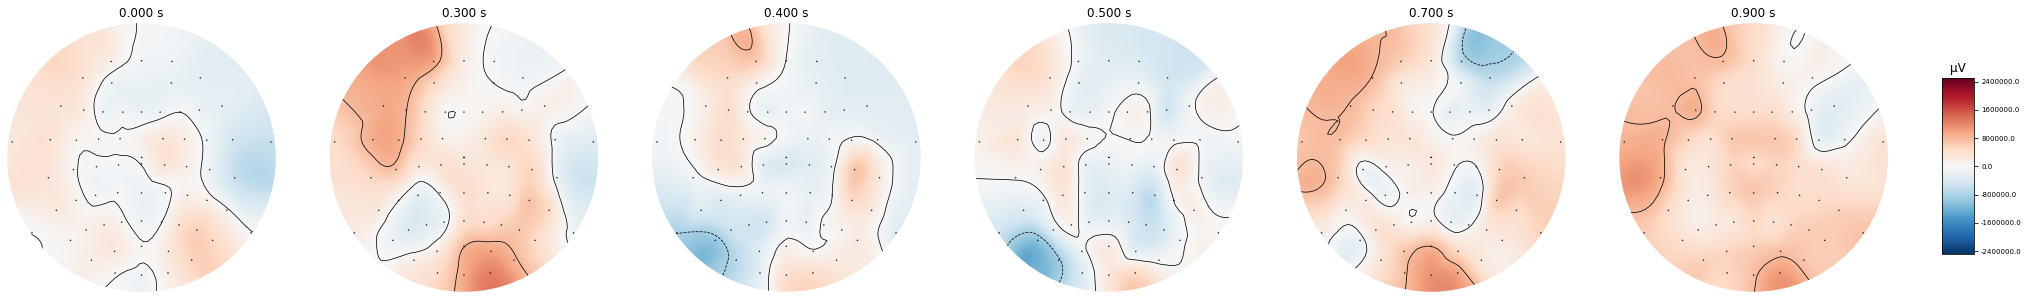

In [5]:
binary_sequence = ""
# 定义目标通道名称
# channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
# channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2']
# 生成二进制掩膜
all_channels = all_sub_human_epoch.ch_names  #  正确变量名
binary_sequence = [1 if ch in channel_names else 0 for ch in all_channels]
print(binary_sequence)
reshaped_sequence = np.tile(binary_sequence, (151, 1)).T  #  转置为 (n_channels, n_times)
print(reshaped_sequence.shape)
vmin, vmax = -2500000, 2500000
# 绘制human条件地形图
evoked_human = all_sub_human_epoch.average()
fig = evoked_human.plot_topomap(
    # mask=reshaped_sequence,
    # mask_params=dict(marker='o', markersize=5, markerfacecolor='black'),
    times=[0, 0.3,  0.4, 0.5, 0.7, 0.9], vmin = vmin, vmax = vmax,
    ch_type='eeg',
    size=3
)
fig.suptitle('Human Topographic Map')  #  添加标题
plt.show()

# 绘制AI条件地形图
evoked_ai = all_sub_AI_epoch.average()
fig = evoked_ai.plot_topomap(
    # mask=reshaped_sequence,
    # mask_params=dict(marker='o', markersize=5, markerfacecolor='black'),
    times=[0, 0.3, 0.4, 0.5, 0.7, 0.9], vmin = vmin, vmax = vmax,
    ch_type='eeg',
    size=3
)
fig.suptitle('AI Topographic Map')  #  添加标题
plt.show()

In [ ]:
# 假设 'epochs' 是你的 EEG epoch 数据
# 只包括vmpfc
# channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2']
# 整个前额
channel_names = ['Fp1', 'Fp2', 'F3', 'Fz', 'F4', 'Fpz', 'AF3', 'AF4', 'F1', 'F2', 'AF7', 'AF8', 'F5', 'F7', 'F6', 'F8']
# channel_names = ['FC5', 'FC3', 'FC1', 'FC2', 'FC4','FC6', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6', 'CP5', 'CP3', 'CP1', 'CPz', 'CP2','CP4', 'CP6']
# channel_names = [ 'FC3', 'FC1', 'FC2', 'FC4', 'C5', 'C3', 'C1', 'Cz', 'C2', 'C4', 'C6',  'CP3', 'CP1', 'CPz', 'CP2','CP4']

# channel_names = ['Pz', 'P1', 'P3', 'P5', 'P7', 'P2', 'P4', 'P6', 'P8','POz', 'PO3', 'PO7', 'PO4', 'PO8', 'Oz', 'O1', 'O2']

# 选择指定的电极信号
all_sub_human_epoch_copy = all_sub_human_epoch.copy()
all_sub_AI_epoch_copy = all_sub_AI_epoch.copy()
pfc_moderate = all_sub_human_epoch_copy.pick_channels(channel_names).average()
pfc_imminent = all_sub_AI_epoch_copy.pick_channels(channel_names).average()
# 绘制平均信号
# evoked.plot(time_unit='s')
# plt.title("Average of Selected Channels")
# plt.show()
# each_sub_mean_data_moderate = np.mean(all_sub_human_epoch.pick_channels(channel_names).get_data(), axis=1)
# each_sub_mean_data_moderate = np.mean(each_sub_mean_data_moderate[:, 50:150], axis=1)

# each_sub_mean_data_imminent = np.mean(all_sub_AI_epoch.pick_channels(channel_names).get_data(), axis=1)
# each_sub_mean_data_imminent = np.mean(each_sub_mean_data_imminent[:, 50:150], axis=1)

In [ ]:
# paired_ttest
def stat_fun_ttest_ind(X,Y):
    return scipy.stats.ttest_rel(X,Y).statistic
from scipy.stats import t
degrees_of_freedom = all_sub_human_epoch_copy.get_data().shape[0] - 1
t_value_threshold = t.ppf(1 - 0.025, degrees_of_freedom)
# print(t_value_threshold)
all_sub_moderate_epoch_copy = all_sub_human_epoch_copy.copy()
all_sub_imminent_epoch_copy = all_sub_AI_epoch_copy.copy()
# all_sub_moderate_epoch_copy.crop(0, 1.2)
# all_sub_imminent_epoch_copy.crop(0, 1.2)

n_permutations = 10000
# 两种情况下相对于0的显著性
T_obs_fast, clusters_Human, cluster_p_values_Human, H0_fast  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_human_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs_slow, clusters_AI, cluster_p_values_AI, H0_slow  = mne.stats.permutation_cluster_1samp_test(np.mean(all_sub_AI_epoch_copy.get_data(), axis=1), 
                                                    out_type='mask',n_permutations=n_permutations, t_power=1, n_jobs=6, tail=0, verbose=None)

T_obs, clusters, cluster_p_values, H0 = mne.stats.permutation_cluster_test([np.mean(all_sub_human_epoch_copy.get_data(), axis=1), np.mean(all_sub_AI_epoch_copy.get_data(), axis=1)],
                                                                out_type='mask', n_permutations=n_permutations, n_jobs=4,tail=0
                                                                ,verbose=None, t_power=0
                                                                ,threshold=t_value_threshold, stat_fun=stat_fun_ttest_ind)
print('moderate')
print(clusters_Human, cluster_p_values_Human)
print('imminent')
print(clusters_AI, cluster_p_values_AI)
print('compare')
print(clusters, cluster_p_values)

In [ ]:
line_color = ['#E36A65','#5CBBBF']    # 红色湖蓝色 正确快攻击，正确慢攻击 
line_color = ['#5CBBBF', '#E36A65']    # 红色湖蓝色 正确快攻击，正确慢攻击 

# line_color = ['#E36A65','#FF943C']    # 红色橙色 正确快攻击，错误快攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#E36A65','#FF943C']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6
# line_color = ['#FF943C', '#E36A65']    # 红色橙色 红色高威胁，橙色低危胁  DE6B48  FFADC6

# line_color = ['#5CBBBF','#4482CD']    #  正确慢攻击，过快慢攻击  DE6B48  FFADC6
# line_color = ['#FF943C','#4482CD']    #  错误快攻击，过快慢攻击  DE6B48  FFADC6

figsize=(10,6) 
title_size=20
legend_size=15

ticksize=10
subplots_adjust=[0.15, 0.15, 0.85, 0.85]


import matplotlib.pyplot as plt
import numpy as np
import os

event_0_line_color = line_color[0]
event_1_line_color = line_color[1]

# the number of time axis
times = all_sub_human_epoch.times

data_1 = np.mean(all_sub_human_epoch_copy.get_data(), axis=1)
data_2 = np.mean(all_sub_AI_epoch_copy.get_data(), axis=1)
plt.close('all')
plt.rcParams['figure.figsize'] = figsize # 设置figure_size尺寸
# plt.title('ROI: '+ roi_name, fontdict={'fontsize':title_size})

epoch_mean={}
epoch_mean[0] = np.squeeze(np.average(data_1, axis=0))
epoch_mean[1] = np.squeeze(np.average(data_2, axis=0))
# plt.plot(times, np.transpose(data_1[-1]))
# plt.legend(subjects)

plt.plot(times, epoch_mean[0], color=line_color[0], alpha=0.9, linewidth=4) # , linestyle='--')
plt.plot(times, epoch_mean[1], color=line_color[1], alpha=0.9, linewidth=4) # , linestyle='--')

# 标注哪条线是哪个event
# legend_font = {'family': fontproperties}
# plt.legend(['Moderate', 'Imminent'], fontsize=legend_size, frameon=False)

# # 画每个电极的线：
# tfr_ROI_epoch_fast.ch_names

# 画0s时的分割线 
# plt.axvline(times[101], c="gray", ls = "dashed")
plt.axvline(times[50], c="gray", ls = "dashed")
plt.plot(times, np.zeros(len(epoch_mean[0])), color="gray", linestyle="--")

# 画误差(std)
std_event0 = np.squeeze(np.std(data_1, axis=0))
std_event1 = np.squeeze(np.std(data_2, axis=0))

se_event0 = std_event0/np.sqrt(data_1.shape[0])
se_event1 = std_event1/np.sqrt(data_2.shape[0])

plt.fill_between(times, epoch_mean[0] - se_event0, epoch_mean[0] + se_event0, color=line_color[0], alpha=0.2)
plt.fill_between(times, epoch_mean[1] - se_event1, epoch_mean[1] + se_event1, color=line_color[1], alpha=0.2)

min_value_1 = np.min(epoch_mean[0] - se_event0)
min_value_2 = np.min(epoch_mean[1] - se_event1)
min_value = np.min([min_value_1, min_value_2])

# event0 的显著性
for i_c, c in enumerate(clusters_Human):
    c = c[0]
    if cluster_p_values_Human[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[0][c.start : c.stop-1], color=event_0_line_color, alpha=0.9, linewidth=10)
# event1 的显著性
for i_c, c in enumerate(clusters_AI):
    c = c[0]
    if cluster_p_values_AI[i_c] <= 0.05:
        # plt.axvspan(times[c.start], times[c.stop - 1], color='r', alpha=0.3)
        plt.plot(times[c.start : c.stop - 1], epoch_mean[1][c.start : c.stop-1], color=event_1_line_color, alpha=0.9, linewidth=10)

# event 间的显著性
for i_c, c in enumerate(clusters):
    c = c[0]
    if cluster_p_values[i_c] <= 0.05:
        
        plt.plot(times[c.start : c.stop - 1], (min_value-0.005) * np.ones(len(epoch_mean[0]))[c.start : c.stop-1], color='#5EACFF', alpha=0.9, linewidth=10)

#hf = plt.plot(times, T_obs, 'g')
plt.legend(['negative influence', 'positive influence'])
plt.subplots_adjust(left=subplots_adjust[0], bottom=subplots_adjust[1], right=subplots_adjust[2], top=subplots_adjust[3], hspace=0.1,wspace=0.1)

plt.xlim([times[0]-0.02, times[-1]+0.02])
# plt.ylim([-3, 17.5])

plt.yticks(size=ticksize)
plt.xticks(size=ticksize)

spines_width = 3
ax=plt.gca()
ax.spines['top'].set_linewidth(0)
ax.spines['right'].set_linewidth(0)
ax.spines['left'].set_linewidth(spines_width)
ax.spines['bottom'].set_linewidth(spines_width)
# sns.despine()

# 坐标轴刻度粗细,朝内
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.major.width'] = 2.5
plt.rcParams['ytick.major.width'] = 2.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
# plt.set_ylabel("Escape Accuracy", size=ticksize, fontproperties='Arial')

labelsize=25
plt.xlabel("Time (s)", fontsize=labelsize, fontproperties='Arial')
plt.ylabel("Theta-band activity", size=labelsize, fontproperties='Arial')

# 坐标的粗细
ticksize = 20
plt.yticks(size=ticksize, fontproperties='Arial')
plt.xticks(size=ticksize, fontproperties='Arial')
# plt.savefig(r'D:\Desktop\项目\seeg\画图\hga_all_new_zlogratio\baseline_insula.jpg',dpi=300, overwrite=True)

# plt.savefig(result_path + '/' + permutation_cluster_result['ROI_name'][ROI_num] + ".png", overwrite=True)